# IDS Challenge: Sub-Projekt 01 Optimization
## Results 

### Group: ___
### Tutor: ___

This is your workspace - implement all submission-relevant functions and elements here and add short text-descriptions that explain your steps. (See `README_EN.ipynb`)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

In [11]:
times = pd.read_csv("data/ls_matrix_55_42.csv", sep='; ', engine="python")

n = 55
time_matrix = np.zeros((n, n))

for row in times.itertuples(index=False):
    i = int(row.start)
    j = int(row.end)
    time_matrix[i][j] = row.ls

np.savetxt("data/timematrix.csv", time_matrix, delimiter=", ")

In [12]:
coords = pd.read_csv("data/allpoint.csv", sep="; ", engine="python")
coords.columns = ["machine", "x", "y", "floor"]
coords = coords.set_index("machine")
depot = 0

In [13]:
penalty = np.zeros(n)

for i in range(n):
    if i == depot:
        continue
    penalty[i] = time_matrix[depot][i] + time_matrix[i][depot]

np.savetxt("data/penalty.csv", penalty, delimiter=", ")

In [6]:
manager = pywrapcp.RoutingIndexManager(n, 3, depot)
routing = pywrapcp.RoutingModel(manager)

In [7]:
def time_callback(from_index, to_index):
    i = manager.IndexToNode(from_index)
    j = manager.IndexToNode(to_index)
    return int(time_matrix[i][j])

time_callback_index = routing.RegisterTransitCallback(time_callback)
routing.SetArcCostEvaluatorOfAllVehicles(time_callback_index)

In [8]:
routing.AddDimension(
    time_callback_index,
    0,
    18000,   # 5 hours
    True,
    "Time"
)

True

In [9]:
for node in range(n):
    if node == depot:
        continue
    routing.AddDisjunction(
        [manager.NodeToIndex(node)],
        int(penalty[node])
    )

In [10]:
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 360

assignment = routing.SolveWithParameters(search_parameters)

In [11]:
routes = []

for v in range(3):
    index = routing.Start(v)
    route = []

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        route.append(node)
        index = assignment.Value(routing.NextVar(index))

    route.append(depot)
    routes.append(route)

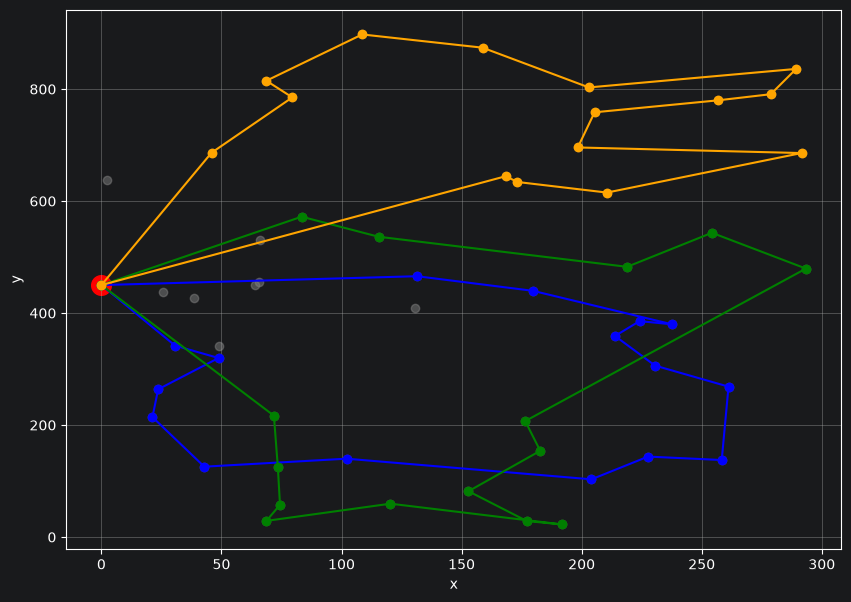

In [12]:
plt.figure(figsize=(10, 7))

plt.scatter(
    coords["x"],
    coords["y"],
    c="gray",
    alpha=0.5,
    label="machines"
)

plt.scatter(
    coords.loc[0, "x"],
    coords.loc[0, "y"],
    c="red",
    s=200,
    label="depot"
)

colors = ["blue", "green", "orange"]

for r_idx, route in enumerate(routes):
    xs = [coords.loc[i, "x"] for i in route]
    ys = [coords.loc[i, "y"] for i in route]
    plt.plot(xs, ys, marker="o", color=colors[r_idx])

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [13]:
def calc_total_tour_time(sequ, matrix):
    total_time = 0
    for i in range(len(sequ)-1):
        total_time += matrix.loc[
            (matrix["start"] == sequ[i]) &
            (matrix["end"] == sequ[i+1]),
            "ls"
        ].iloc[0]
    return total_time

In [14]:
count = 1
for i in routes:
    tour_time_sec = calc_total_tour_time(i, times)
    print(f"Total time for tour {count}: {tour_time_sec} seconds")
    print(f"Total time for tour {count}: {tour_time_sec/60} minutes")
    print(f"Total time for tour {count}: {tour_time_sec/3600} hours")
    print()
    count+=1

Total time for tour 1: 17962.54006009211 seconds
Total time for tour 1: 299.3756676682018 minutes
Total time for tour 1: 4.989594461136697 hours

Total time for tour 2: 17850.320608382215 seconds
Total time for tour 2: 297.50534347303693 minutes
Total time for tour 2: 4.958422391217282 hours

Total time for tour 3: 17779.001183976863 seconds
Total time for tour 3: 296.3166863996144 minutes
Total time for tour 3: 4.938611439993573 hours

